# Spectrogram Generation for Call Classification Model Training

### This notebook generates spectrograms in PyTorch (.pt) format from audio files to train the beluga call classification model.

We used to have dataset using 3s snippets, but then moved to 1s and labeled all the overlaps, as we move forward we should clean up how we handle the data, to have cleaner code.



In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/mnt/home/test/beluga-call-pipeline/


In [2]:

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import librosa
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator
import pandas as pd
import torch
import numpy as np

from tqdm import tqdm
import os


In [3]:
#Loading the labels for the overlaps
labels_df_3sec = pd.read_csv("../data/Verified_Dataset/labels/labels_merged_3sec.csv")


In [4]:
spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [5]:

DATA_DIRECTORY = "../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

output_dir = DATA_DIRECTORY + "Verified_Dataset/spectrograms_3sec/"

ECHO:  1
HFPC:  0
BBPC:  1
Whistle:  1
Call:  1
Boat:  1.0
Testing with: BSM_20170724_13465400_s3.wav
  Clip 1: BSM_20170724_13465400.wav
  Clip 2: BSM_20170724_13465500.wav
  Clip 3: BSM_20170724_13465600.wav

Individual audio shapes:
  Audio 1: (192000,) (duration: 1.00s)
  Audio 2: (192000,) (duration: 1.00s)
  Audio 3: (192000,) (duration: 1.00s)

Combined audio shape: (576000,) (duration: 3.00s)


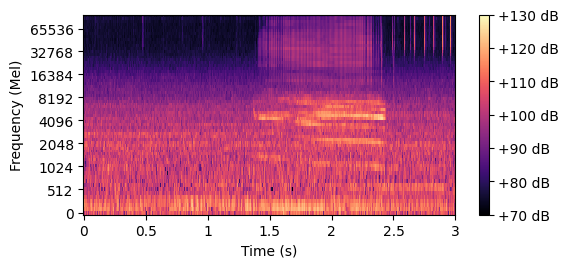

In [46]:
# Test: Verify that audio merging works correctly
test_row = labels_df_3sec[labels_df_3sec["BBPC"] == 1].iloc[5]
print("ECHO: ", test_row["ECHO"])
print("HFPC: ", test_row["HFPC"])
print("BBPC: ", test_row["BBPC"])
print("Whistle: ", test_row["Whistle"])
print("Call: ", test_row["Call"])
print("Boat: ", test_row["Boat"])
print(f"Testing with: {test_row['clip_filename']}")
print(f"  Clip 1: {test_row['clip_1']}")
print(f"  Clip 2: {test_row['clip_2']}")  
print(f"  Clip 3: {test_row['clip_3']}")


# Load individual clips
audio_1, sr, _ = spect_generator.load_audio(wavs_folder + test_row["clip_1"])
audio_2, sr, _ = spect_generator.load_audio(wavs_folder + test_row["clip_2"])
audio_3, sr, _ = spect_generator.load_audio(wavs_folder + test_row["clip_3"])

print(f"\nIndividual audio shapes:")
print(f"  Audio 1: {audio_1.shape} (duration: {len(audio_1)/sr:.2f}s)")
print(f"  Audio 2: {audio_2.shape} (duration: {len(audio_2)/sr:.2f}s)")
print(f"  Audio 3: {audio_3.shape} (duration: {len(audio_3)/sr:.2f}s)")

# Concatenate
audio_combined = np.concatenate([audio_1, audio_2, audio_3], axis=0)
print(f"\nCombined audio shape: {audio_combined.shape} (duration: {len(audio_combined)/sr:.2f}s)")

# Generate spectrogram
power_spect = spect_generator.compute_mel_power_spect(audio_combined)
dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=test_row["HydrophoneSensitivity"])
dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))
spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)



In [50]:

os.makedirs(output_dir, exist_ok=True)

# Get list of already processed files
processed_files = set(os.listdir(output_dir))

df_to_process = labels_df_3sec  # Use 3-second labels

for index, row in tqdm(df_to_process.iterrows(), total=df_to_process.shape[0]):
    processed_filename = row["clip_filename"].replace(".wav", ".pt")
    
    # Skip if file already exists
    if processed_filename in processed_files:
        continue

    try:
        # Load the three 1-second audio clips
        audio_1, sr, original_sr = spect_generator.load_audio(wavs_folder + row["clip_1"])
        audio_2, sr, original_sr = spect_generator.load_audio(wavs_folder + row["clip_2"])
        audio_3, sr, original_sr = spect_generator.load_audio(wavs_folder + row["clip_3"])
        
        # Concatenate the three audio clips into one 3-second audio
        audio_combined = np.concatenate([audio_1, audio_2, audio_3], axis=0)
        
        # Generate spectrogram from the combined 3-second audio
        power_spect = spect_generator.compute_mel_power_spect(audio_combined)
        
        dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
        
        dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
        
        dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))
        
        dB_spect_resized = np.float32(dB_spect_resized)
        # Save the 3-second spectrogram
        torch.save(dB_spect_resized, output_dir + processed_filename)
        # break
        
    except FileNotFoundError as e:
        print(f"File not found for {row['clip_filename']}: {e}")
    except Exception as e:
        print(f"Error processing {row['clip_filename']}: {e}")

  0%|          | 4/9745 [00:00<04:59, 32.57it/s]

100%|██████████| 9745/9745 [09:12<00:00, 17.63it/s]


Testing with: BSM_20170724_13385800_s3.wav
  Clip 1: BSM_20170724_13385800.wav
  Clip 2: BSM_20170724_13385900.wav
  Clip 3: BSM_20170724_13390000.wav


/mnt/home/test/beluga-call-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Individual audio shapes:
  Audio 1: (192000,) (duration: 1.00s)
  Audio 2: (192000,) (duration: 1.00s)
  Audio 3: (192000,) (duration: 1.00s)


TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray

## Running the some tests using our trained model to make sure everything works correctly

In [6]:
from models.quant_mobilenet import load_mobilenet_v3_quant_from_file
from models.utils import get_best_device


model = load_mobilenet_v3_quant_from_file("../models/weights/mobile_net_8_layers_qat.pt", n_layers=8)

device = get_best_device()

model.to(device)

/mnt/home/test/beluga-call-pipeline/models/quant_mobilenet.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")
Downloading

QuantizableMobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): QuantizableInvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU()
        )
        (1): QuantizableSqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
          (skip_mul): FloatFunctional(
            (activation_post_proces

CAC_20210714_08401400_s3.wav ECHO HFPC Whistle 
Boat:  1.0
evaluation_v1
(244, 244)


/tmp/ipykernel_1875020/1209221390.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  spect = torch.load(output_dir +processed_filename)


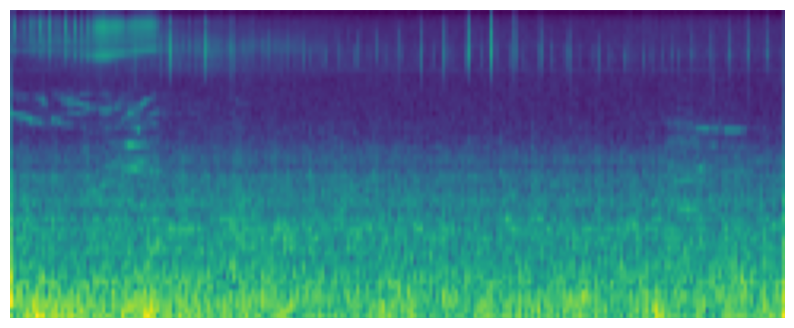

BSM_20170729_14141659_s3.wav ECHO HFPC Whistle 
Boat:  1.0
irene_5min
(244, 244)


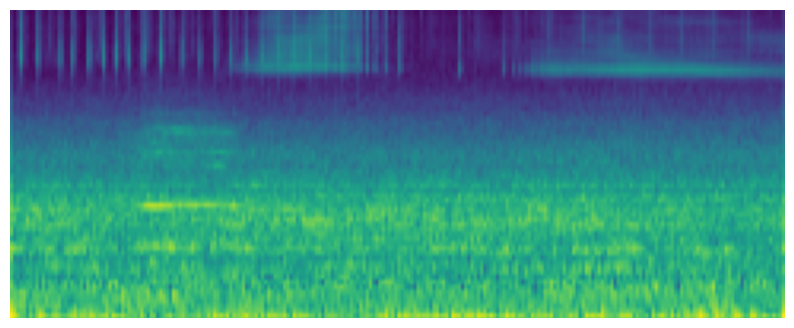

KAM_20200726_19212700_s3.wav ECHO Whistle 
Boat:  1.0
evaluation_v1
(244, 244)


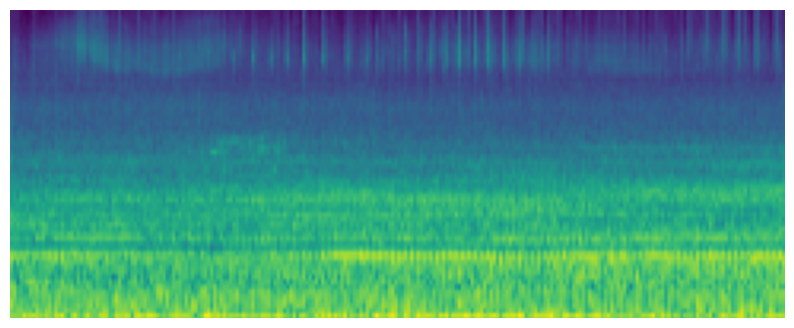

CAC_20210714_08392400_s3.wav ECHO Whistle 
Boat:  1.0
evaluation_v1
(244, 244)


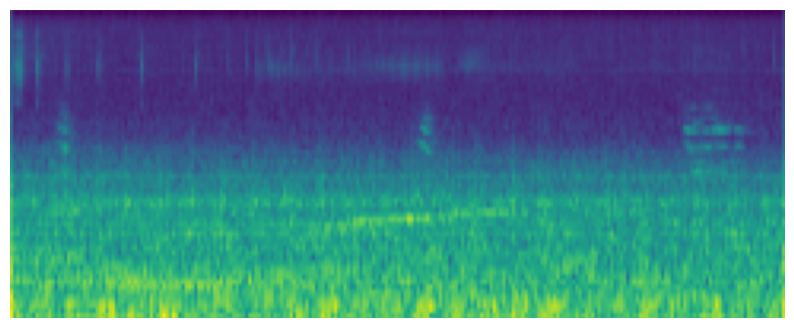

CAC_20210714_08395800_s3.wav ECHO Whistle 
Boat:  1.0
evaluation_v1
(244, 244)


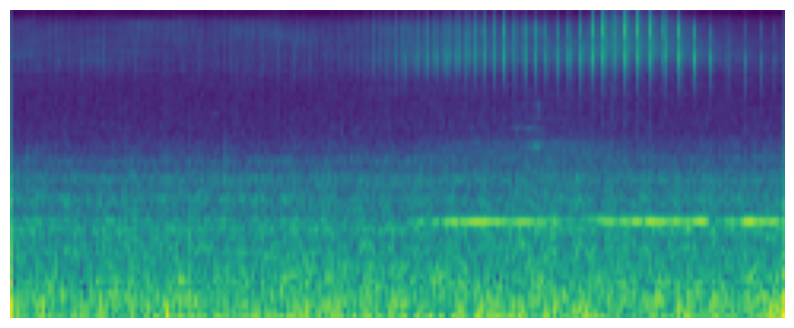

CAC_20210714_08380000_s3.wav ECHO Whistle 
Boat:  1.0
evaluation_v1
(244, 244)


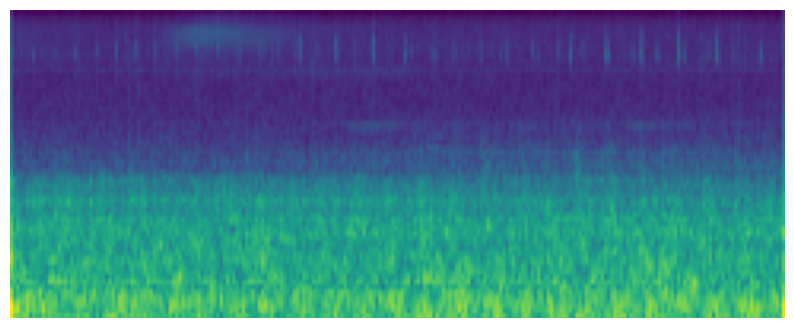

CAC_20210804_13293400_s3.wav BBPC Whistle 
Boat:  1.0
evaluation_v2
(244, 244)


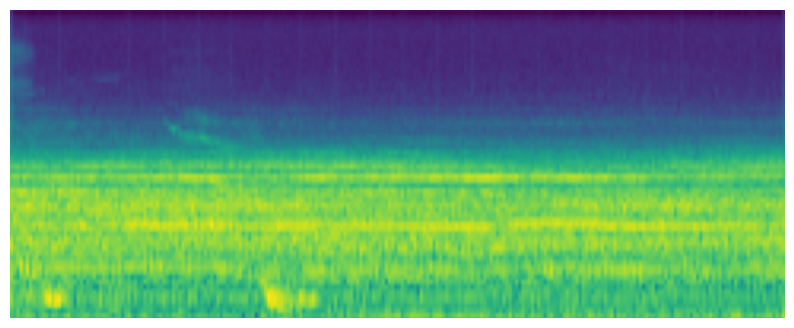

KAM_20200729_11321500_s3.wav ECHO Whistle 
Boat:  1.0
evaluation_v2
(244, 244)


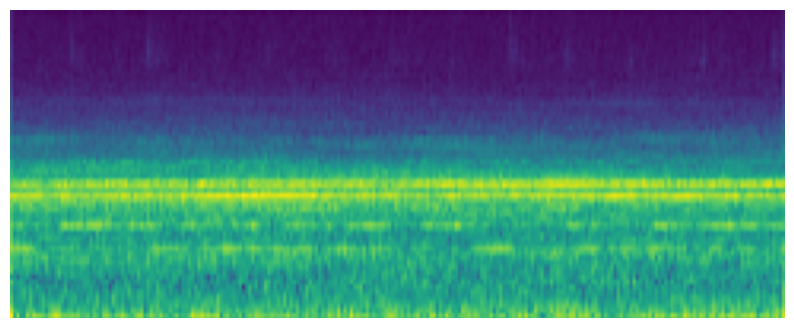

KAM_20210728_13314900_s3.wav ECHO BBPC Whistle 
Boat:  1.0
irene_5min
(244, 244)


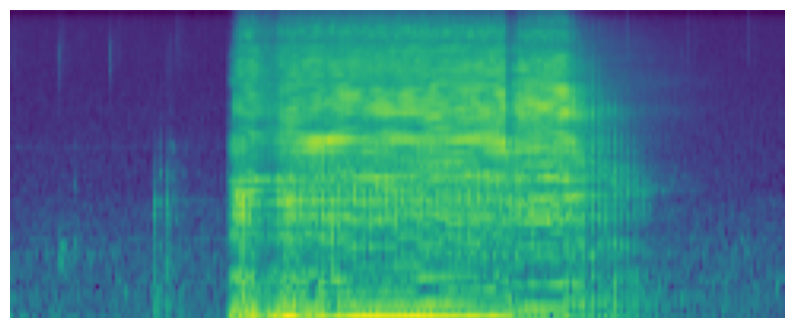

CAC_20210714_08351800_s3.wav ECHO Whistle 
Boat:  1.0
evaluation_v1
(244, 244)


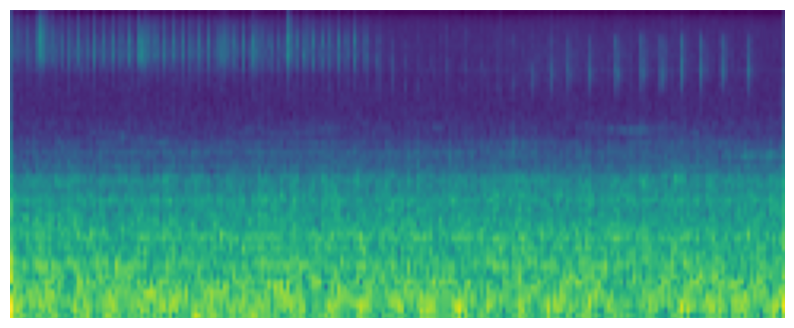

In [30]:

DATA_DIRECTORY = "../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

# sample = labels_df[labels_df["Notes"].notna()]
# sample = labels_df[labels_df["clip_filename"] == "CAC_20210714_08342600.wav"]
sample = labels_df_3sec[(labels_df_3sec["Boat"] == 1) & (labels_df_3sec["Whistle"] == 1)].sample(10)




for index, row in sample.iterrows():    
    processed_filename = row["clip_filename"].replace(".wav", ".pt")
    
    title = ""
    title += f"{row['clip_filename']} "
    if row['ECHO'] == 1:
        title += "ECHO "
    if row['HFPC'] == 1:
        title += "HFPC "
    if row['BBPC'] == 1:
        title += "BBPC "
    if row['Whistle'] == 1:
        title += "Whistle "
    
    print(title)
    print("Boat: ", row["Boat"])

    print(row["labeling_effort"])

    spect = torch.load(output_dir +processed_filename)
    print(spect.shape)
    plt.figure(figsize=(10, 4))
    plt.imshow(spect, aspect='auto', origin='lower')
    plt.axis('off')
    plt.show()

    # file_path = wavs_folder + row["clip_filename"]

    # audio, sr, original_sr = spect_generator.load_audio(file_path)


    # power_spect = spect_generator.compute_mel_power_spect(audio)

    
    # dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
  

    # spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

    # dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    # dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    

(192000,)
-0.004742104
-0.0036230558
dB_spect
(64, 188)
58.286278
127.47009


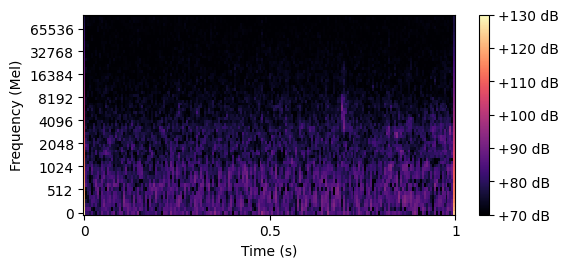

In [85]:
file_path = "../data/Verified_Dataset/clip_wavs/BSM_20210818_17440200.wav"
# file_path = "../data/Full_Dataset/Snippets_3s_wav/BSM_20210818_174400.wav"

audio, sr, original_sr = spect_generator.load_audio(file_path)

print(audio.shape)
print(min(audio))
print(max(audio))

power_spect = spect_generator.compute_mel_power_spect(audio)



dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=-172.7)
print("dB_spect")
print(dB_spect.shape)
print(dB_spect.min())
print(dB_spect.max())

spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)


In [49]:
spect = torch.load(output_dir +"BSM_20170724_13385800_s3.pt")
print("Spectrogram shape:", spect.shape)
print("Spectrogram dtype:", spect.dtype)

Spectrogram shape: (244, 244)
Spectrogram dtype: float32


/tmp/ipykernel_1875020/1274797405.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  spect = torch.load(output_dir +"BSM_20170724_13385800_s3.pt")


C:\Users\Admin\AppData\Local\Temp\ipykernel_797112\3097811221.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  spect = torch.load(output_dir +"BSM_20170724_09480100.pt")


(244, 244)


c:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


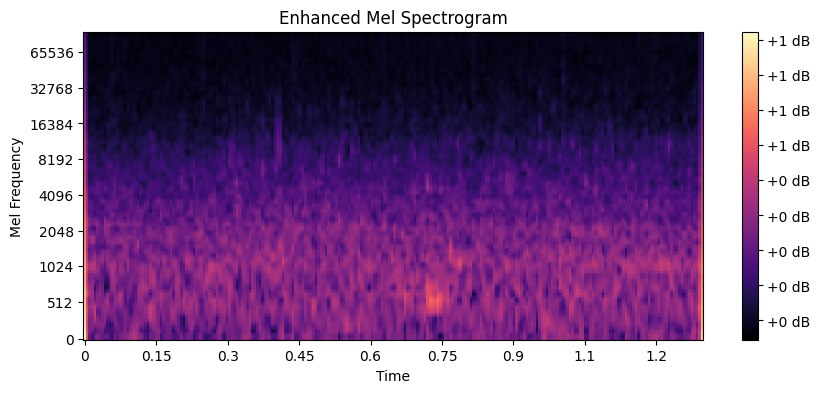

In [6]:
import torch
import matplotlib.pyplot as plt
import librosa
spect = torch.load(output_dir +"BSM_20170724_09480100.pt")
# plt.figure(figsize=(10, 4))
sr = 192000
# plt.imshow(spect, aspect='auto', origin='lower')
# res = classify(spect, model, device)
# print(res)
# plt.show(block=False)
print(spect.shape)
plt.figure(figsize=(10, 4))
librosa.display.specshow(spect, sr=sr, hop_length=1024, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Enhanced Mel Spectrogram')
plt.xlabel('Time')
plt.ylabel('Mel Frequency')
plt.show()